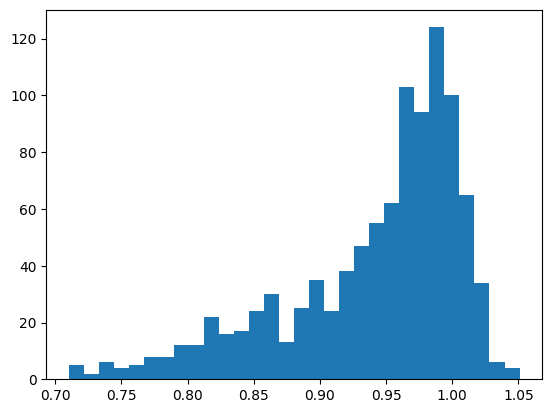

In [23]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
import sklearn 
from random import sample
from sklearn.neighbors import KernelDensity
import scipy

sigma=0.02
mu=1

chi=np.random.uniform(0,1,1000)
M=np.random.normal(mu,sigma,1000)

def f(X): 
    return np.sqrt((1+np.sqrt(1-X**2))/2)

M_irr=M*f(chi)
plt.hist(M_irr,30)
plt.show()
  

Using KDE

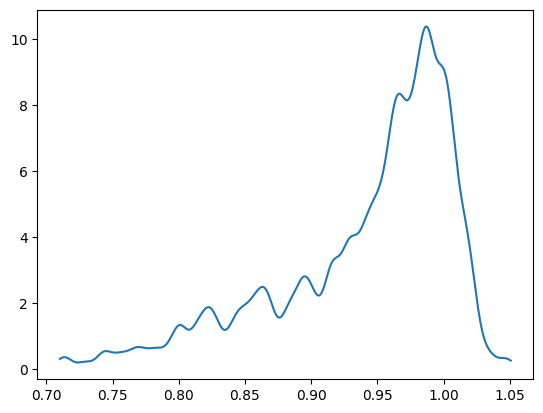

In [24]:
xgrid = np.linspace(M_irr.min(),M_irr.max(),1000) #x of KDE 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):

    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFGaussian = kde_sklearn(M_irr,bandwidth=0.005,kernel="gaussian")  
plt.plot(xgrid,PDFGaussian);

In [ ]:


scipy.stats.ks_2samp(M_irr,f(chi)).pvalue




np.float64(1.382902816518576e-11)